# Regressão com Spark

Construindo um modelo de regressão que tem como objetivo prever preços de ímoveis, com base em suas caracteristicas

In [2]:
!pip install pyspark

In [3]:
from pyspark.sql import SparkSession
spark = SparkSession.builder\
                    .master('local[*]')\
                    .appName('Regressão com Spark')\
                    .getOrCreate()

spark

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
df = spark.read.json(
    '/content/drive/MyDrive/regressao_com_spark/imoveis.json'
)

In [6]:
df

DataFrame[ident: struct<customerID:string,source:string>, listing: struct<address:struct<city:string,location:struct<lat:double,lon:double>,neighborhood:string,zone:string>,features:struct<bathrooms:bigint,bedrooms:bigint,floors:bigint,parkingSpaces:bigint,suites:bigint,totalAreas:string,unitFloor:bigint,unitsOnTheFloor:bigint,usableAreas:string>,prices:struct<price:string,tax:struct<condo:string,iptu:string>>,types:struct<unit:string,usage:string>>]

In [7]:

df.show(truncate=False)

+--------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------+
|ident                     |listing                                                                                                                                                          |
+--------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------+
|{775564-BOJSMVON, Website}|{{Rio de Janeiro, {-22.909429, -43.413557}, Taquara, Zona Oeste}, {0, 0, 0, 1, 0, 62, 0, 0, 62}, {45000, {150, 0}}, {Outros, Residencial}}                       |
|{660895-AUENKNYY, Website}|{{Rio de Janeiro, {-22.869698, -43.509141}, Santíssimo, Zona Oeste}, {1, 2, 0, 1, 0, 0, 0, 0, 44}, {45000, {120, 0}}, {Apartamento, Residencial}}                |
|{751522-JESYFEQL, Website}|{{Rio de Janeiro,

In [8]:
df.count()

73615

**Seleção de features**

In [9]:
# verificando o schema dos dados
df.printSchema()

df\
  .select('ident.customerID', 'listing.*')\
  .show(truncate=False)

root
 |-- ident: struct (nullable = true)
 |    |-- customerID: string (nullable = true)
 |    |-- source: string (nullable = true)
 |-- listing: struct (nullable = true)
 |    |-- address: struct (nullable = true)
 |    |    |-- city: string (nullable = true)
 |    |    |-- location: struct (nullable = true)
 |    |    |    |-- lat: double (nullable = true)
 |    |    |    |-- lon: double (nullable = true)
 |    |    |-- neighborhood: string (nullable = true)
 |    |    |-- zone: string (nullable = true)
 |    |-- features: struct (nullable = true)
 |    |    |-- bathrooms: long (nullable = true)
 |    |    |-- bedrooms: long (nullable = true)
 |    |    |-- floors: long (nullable = true)
 |    |    |-- parkingSpaces: long (nullable = true)
 |    |    |-- suites: long (nullable = true)
 |    |    |-- totalAreas: string (nullable = true)
 |    |    |-- unitFloor: long (nullable = true)
 |    |    |-- unitsOnTheFloor: long (nullable = true)
 |    |    |-- usableAreas: string (nullable =

In [10]:
df\
  .select('ident.customerID', 'listing.types.*', 'listing.features.*', 'listing.address.*', 'listing.prices.price', 'listing.prices.tax.*')\
  .show(truncate=False)

+---------------+-----------+-----------+---------+--------+------+-------------+------+----------+---------+---------------+-----------+--------------+------------------------+------------------------+------------+-----+-----+----+
|customerID     |unit       |usage      |bathrooms|bedrooms|floors|parkingSpaces|suites|totalAreas|unitFloor|unitsOnTheFloor|usableAreas|city          |location                |neighborhood            |zone        |price|condo|iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+----------+---------+---------------+-----------+--------------+------------------------+------------------------+------------+-----+-----+----+
|775564-BOJSMVON|Outros     |Residencial|0        |0       |0     |1            |0     |62        |0        |0              |62         |Rio de Janeiro|{-22.909429, -43.413557}|Taquara                 |Zona Oeste  |45000|150  |0   |
|660895-AUENKNYY|Apartamento|Residencial|1        |2       |0     |1

In [11]:
# seleção de features

df = df\
  .select('ident.customerID', 'listing.types.*', 'listing.features.*', 'listing.address.*', 'listing.prices.price', 'listing.prices.tax.*')\
  .drop('city', 'location', 'totalAreas')

In [12]:
df = spark.read.json(
    '/content/drive/MyDrive/regressao_com_spark/imoveis.json'
)
dataset = df.select('ident.customerID', 'listing.types.*', 'listing.features.*', 'listing.address.*', 'listing.prices.price', 'listing.prices.tax.*').drop('city', 'location', 'totalAreas')

In [13]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-----+-----+----+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|price|condo|iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-----+-----+----+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000|  150|   0|
|660895-AUENKNYY|Apartamento|Residencial|        1|       2|     0|            1|     0|        0|              0|         44|          Santíssimo|  Zona Oeste|45000|  120|   0|
|751522-JESYFEQL|     Outros|Residencial|        0|       0|     0|            0|     0|        0|            

**Tratamento de dados**

In [14]:
dataset.printSchema()

root
 |-- customerID: string (nullable = true)
 |-- unit: string (nullable = true)
 |-- usage: string (nullable = true)
 |-- bathrooms: long (nullable = true)
 |-- bedrooms: long (nullable = true)
 |-- floors: long (nullable = true)
 |-- parkingSpaces: long (nullable = true)
 |-- suites: long (nullable = true)
 |-- unitFloor: long (nullable = true)
 |-- unitsOnTheFloor: long (nullable = true)
 |-- usableAreas: string (nullable = true)
 |-- neighborhood: string (nullable = true)
 |-- zone: string (nullable = true)
 |-- price: string (nullable = true)
 |-- condo: string (nullable = true)
 |-- iptu: string (nullable = true)



In [15]:
# mudando o type de algumas colunas com withColumn

from pyspark.sql.types import IntegerType, DoubleType

dataset\
    .withColumn('usableAreas', dataset['usableAreas'].cast(IntegerType()))\
    .withColumn('condo', dataset['condo'].cast(DoubleType()))\
    .withColumn('price', dataset['price'].cast(DoubleType()))\
    .withColumn('iptu', dataset['iptu'].cast(DoubleType()))\
    .printSchema()

root
 |-- customerID: string (nullable = true)
 |-- unit: string (nullable = true)
 |-- usage: string (nullable = true)
 |-- bathrooms: long (nullable = true)
 |-- bedrooms: long (nullable = true)
 |-- floors: long (nullable = true)
 |-- parkingSpaces: long (nullable = true)
 |-- suites: long (nullable = true)
 |-- unitFloor: long (nullable = true)
 |-- unitsOnTheFloor: long (nullable = true)
 |-- usableAreas: integer (nullable = true)
 |-- neighborhood: string (nullable = true)
 |-- zone: string (nullable = true)
 |-- price: double (nullable = true)
 |-- condo: double (nullable = true)
 |-- iptu: double (nullable = true)



In [16]:
dataset = dataset\
    .withColumn('usableAreas', dataset['usableAreas'].cast(IntegerType()))\
    .withColumn('condo', dataset['condo'].cast(DoubleType()))\
    .withColumn('price', dataset['price'].cast(DoubleType()))\
    .withColumn('iptu', dataset['iptu'].cast(DoubleType()))

In [17]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+------+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  price|condo|  iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+------+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|   0.0|
|660895-AUENKNYY|Apartamento|Residencial|        1|       2|     0|            1|     0|        0|              0|         44|          Santíssimo|  Zona Oeste|45000.0|120.0|   0.0|
|751522-JESYFEQL|     Outros|Residencial|        0|       0|     0|            0|     0|  

In [18]:
dataset\
    .select('usage')\
    .groupBy('usage')\
    .count()\
    .show()

+-----------+-----+
|      usage|count|
+-----------+-----+
|  Comercial| 4019|
|Residencial|69596|
+-----------+-----+



In [19]:
# pegando somente dados de casas residenciais
dataset = dataset\
    .select('*')\
    .where('usage=="Residencial"')

In [20]:
dataset\
    .select('unit')\
    .groupBy('unit')\
    .count()\
    .show()

+-----------+-----+
|       unit|count|
+-----------+-----+
|     Outros| 1190|
|Apartamento|59106|
|       Casa| 9300|
+-----------+-----+



In [21]:
# verificando a coluna zona

dataset\
    .select('zone')\
    .groupBy('zone')\
    .count()\
    .show()

+------------+-----+
|        zone|count|
+------------+-----+
|  Zona Norte|14379|
|  Zona Oeste|35523|
|Zona Central| 1002|
|    Zona Sul|18535|
|            |  157|
+------------+-----+



**Dados faltantes**

In [22]:
from pyspark.sql import functions as f

In [23]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  price|condo| iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|  0.0|
|660895-AUENKNYY|Apartamento|Residencial|        1|       2|     0|            1|     0|        0|              0|         44|          Santíssimo|  Zona Oeste|45000.0|120.0|  0.0|
|751522-JESYFEQL|     Outros|Residencial|        0|       0|     0|            0|     0|       

In [24]:
# contagem booleana quando valor coluna for nan ou null
dataset\
    .select([f.count(f.when(f.isnull(c), True)).alias(c) for c in dataset.columns])\
    .show()

+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+
|customerID|unit|usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|neighborhood|zone|price|condo|iptu|
+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+
|         0|   0|    0|        0|       0|     0|            0|     0|        0|              0|          0|           0|   0|    0| 6061|8726|
+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+



In [25]:
# substituindo valores nulos por 0
dataset\
    .select('*')\
    .na\
    .fill(0)\
    .show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  price|condo| iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|  0.0|
|660895-AUENKNYY|Apartamento|Residencial|        1|       2|     0|            1|     0|        0|              0|         44|          Santíssimo|  Zona Oeste|45000.0|120.0|  0.0|
|751522-JESYFEQL|     Outros|Residencial|        0|       0|     0|            0|     0|       

In [26]:
dataset = dataset\
    .select('*')\
    .na\
    .fill(0)

In [27]:
# verificando de novo quantos valores nulos tenho para cada uma das colunas

dataset\
    .select([f.count(f.when(f.isnull(c), True)).alias(c) for c in dataset.columns])\
    .show()

+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+
|customerID|unit|usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|neighborhood|zone|price|condo|iptu|
+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+
|         0|   0|    0|        0|       0|     0|            0|     0|        0|              0|          0|           0|   0|    0|    0|   0|
+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+



In [28]:
dataset\
    .select('zone')\
    .groupBy('zone')\
    .count()\
    .show()

+------------+-----+
|        zone|count|
+------------+-----+
|  Zona Norte|14379|
|  Zona Oeste|35523|
|Zona Central| 1002|
|    Zona Sul|18535|
|            |  157|
+------------+-----+



In [29]:
# tratando a string vazia
# definindo dataset como dataset = dataset sem os valores nulos em 'zone'

dataset = dataset\
    .where(f.col('zone') != '')

# **Regressão Linear**

resumindo os dados a uma função linear

**Preparação dos dados:** variáveis dummy

In [30]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  price|condo| iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|  0.0|
|660895-AUENKNYY|Apartamento|Residencial|        1|       2|     0|            1|     0|        0|              0|         44|          Santíssimo|  Zona Oeste|45000.0|120.0|  0.0|
|751522-JESYFEQL|     Outros|Residencial|        0|       0|     0|            0|     0|       

In [31]:
# transformando as variáveis em variáveis númericas

dataset\
  .groupBy ('customerID')\
  .pivot('unit')\
  .agg(f.lit(1))\
  .na\
  .fill(0)\
  .show()


+---------------+-----------+----+------+
|     customerID|Apartamento|Casa|Outros|
+---------------+-----------+----+------+
|062130-QKYMWGMV|          1|   0|     0|
|630945-AEEUPRXI|          0|   1|     0|
|994985-OZQNHQKH|          1|   0|     0|
|494674-JWXRZIBM|          1|   0|     0|
|458844-UJCRFSRI|          1|   0|     0|
|155284-BRCDAOIQ|          1|   0|     0|
|396742-DUXBHLRU|          1|   0|     0|
|916072-ZJXARAXO|          1|   0|     0|
|943843-BVTWWHRQ|          1|   0|     0|
|193126-MTNIIFQN|          1|   0|     0|
|319762-UXTTQYFS|          1|   0|     0|
|931151-GZCTKADB|          1|   0|     0|
|103840-OFKPFEZJ|          0|   1|     0|
|176885-NNKZRQGM|          0|   1|     0|
|926638-PBYRAZYR|          1|   0|     0|
|744421-IZJWISWB|          1|   0|     0|
|530012-TYGLQMER|          1|   0|     0|
|209407-GTEUOVKR|          1|   0|     0|
|289667-ZPHGFHJH|          1|   0|     0|
|859388-EYTPMKER|          1|   0|     0|
+---------------+-----------+----+

In [32]:
unit = dataset\
  .groupBy ('customerID')\
  .pivot('unit')\
  .agg(f.lit(1))\
  .na\
  .fill(0)

In [33]:
zone = dataset\
  .groupBy ('customerID')\
  .pivot('zone')\
  .agg(f.lit(1))\
  .na\
  .fill(0)

In [34]:
dataset = dataset\
    .join(unit, 'customerID', how='inner')\
    .join(zone, 'customerID', how='inner')

In [35]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+-----------+----+------+------------+----------+----------+--------+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  price|condo| iptu|Apartamento|Casa|Outros|Zona Central|Zona Norte|Zona Oeste|Zona Sul|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+-----------+----+------+------------+----------+----------+--------+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|  0.0|          0|   0|     1|           0|         0|         1|       0|
|660

In [36]:
dataset.columns

['customerID',
 'unit',
 'usage',
 'bathrooms',
 'bedrooms',
 'floors',
 'parkingSpaces',
 'suites',
 'unitFloor',
 'unitsOnTheFloor',
 'usableAreas',
 'neighborhood',
 'zone',
 'price',
 'condo',
 'iptu',
 'Apartamento',
 'Casa',
 'Outros',
 'Zona Central',
 'Zona Norte',
 'Zona Oeste',
 'Zona Sul']

**Vetorização dos dados**

In [37]:
from pyspark.ml.feature import VectorAssembler

In [38]:
dataset = dataset.withColumnRenamed('price', 'label')

In [39]:
x = [
 'bathrooms',
 'bedrooms',
 'floors',
 'parkingSpaces',
 'suites',
 'unitFloor',
 'unitsOnTheFloor',
 'usableAreas',
 'condo',
 'iptu',
 'Apartamento',
 'Casa',
 'Outros',
 'Zona Central',
 'Zona Norte',
 'Zona Oeste',
 'Zona Sul'
]

In [40]:
assembler = VectorAssembler(inputCols = x, outputCol = 'features')

In [41]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+-----------+----+------+------------+----------+----------+--------+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  label|condo| iptu|Apartamento|Casa|Outros|Zona Central|Zona Norte|Zona Oeste|Zona Sul|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+-----------+----+------+------------+----------+----------+--------+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|  0.0|          0|   0|     1|           0|         0|         1|       0|
|660

In [42]:
dataset_prep = assembler.transform(dataset).select('features', 'label')

In [43]:
dataset_prep.show(10, truncate=False)

+--------------------------------------------------------------------------+-------+
|features                                                                  |label  |
+--------------------------------------------------------------------------+-------+
|(17,[3,7,8,12,15],[1.0,62.0,150.0,1.0,1.0])                               |45000.0|
|(17,[0,1,3,7,8,10,15],[1.0,2.0,1.0,44.0,120.0,1.0,1.0])                   |45000.0|
|(17,[7,8,12,15],[132.0,100.0,1.0,1.0])                                    |50000.0|
|[2.0,3.0,3.0,1.0,1.0,2.0,4.0,60.0,400.0,120.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0]|50000.0|
|(17,[7,12,15],[200.0,1.0,1.0])                                            |50000.0|
|(17,[0,1,3,7,10,14],[1.0,1.0,1.0,33.0,1.0,1.0])                           |45336.0|
|(17,[7,12,15],[120.0,1.0,1.0])                                            |45000.0|
|(17,[7,12,15],[468.0,1.0,1.0])                                            |45000.0|
|(17,[5,7,12,15],[1.0,180.0,1.0,1.0])                            

**Exploração dos Dados**

In [44]:
from pyspark.ml.stat import Correlation
import pandas as pd

In [45]:
correlacao = Correlation.corr(dataset_prep, 'features').collect()

In [46]:
correlacao

[Row(pearson(features)=DenseMatrix(17, 17, [1.0, 0.6659, -0.0446, 0.4876, 0.7529, 0.0076, -0.1074, 0.5981, ..., 0.0088, 0.1803, -0.1833, -0.0165, -0.073, -0.3084, -0.6176, 1.0], False))]

In [47]:
correlacao = Correlation.corr(dataset_prep, 'features').collect()[0][0]

In [48]:
correlacao

DenseMatrix(17, 17, [1.0, 0.6659, -0.0446, 0.4876, 0.7529, 0.0076, -0.1074, 0.5981, ..., 0.0088, 0.1803, -0.1833, -0.0165, -0.073, -0.3084, -0.6176, 1.0], False)

In [49]:
# trazendo a matriz para um array

correlacao.toArray()

array([[ 1.00000000e+00,  6.65910814e-01, -4.45907541e-02,
         4.87590447e-01,  7.52927830e-01,  7.62425469e-03,
        -1.07437445e-01,  5.98072790e-01,  2.00298945e-02,
         1.51023977e-02, -2.75457964e-01,  3.43042378e-01,
        -1.40183420e-01, -9.73678190e-02, -1.62497441e-01,
         2.42345124e-01, -9.87517576e-02],
       [ 6.65910814e-01,  1.00000000e+00, -8.21840063e-02,
         4.67161260e-01,  6.01199220e-01, -7.16195849e-03,
        -1.30814438e-01,  5.63750247e-01,  1.84819307e-02,
         1.36391535e-02, -2.58339018e-01,  3.49962189e-01,
        -2.05607705e-01, -1.23732152e-01, -1.11711865e-01,
         1.63821698e-01, -4.94325200e-02],
       [-4.45907541e-02, -8.21840063e-02,  1.00000000e+00,
        -4.84861921e-02, -4.81062141e-02,  1.20981700e-01,
         7.37717422e-01, -1.03916850e-01,  1.37973623e-02,
         6.68849447e-03,  1.53947015e-01, -1.42089598e-01,
        -5.19462291e-02,  1.26044467e-01, -1.69262936e-02,
        -3.17495417e-02,  1.7

In [50]:
dataframe_corr = pd.DataFrame(correlacao.toArray(), columns=x, index=x)

In [51]:
dataframe_corr

,bathrooms,bedrooms,floors,parkingSpaces,suites,unitFloor,unitsOnTheFloor,usableAreas,condo,iptu,Apartamento,Casa,Outros,Zona Central,Zona Norte,Zona Oeste,Zona Sul
bathrooms,1.000000,0.665911,-0.044591,0.487590,0.752928,0.007624,-0.107437,0.598073,0.020030,0.015102,-0.275458,0.343042,-0.140183,-0.097368,-0.162497,0.242345,-0.098752
bedrooms,0.665911,1.000000,-0.082184,0.467161,0.601199,-0.007162,-0.130814,0.563750,0.018482,0.013639,-0.258339,0.349962,-0.205608,-0.123732,-0.111712,0.163822,-0.049433
floors,-0.044591,-0.082184,1.000000,-0.048486,-0.048106,0.120982,0.737717,-0.103917,0.013797,0.006688,0.153947,-0.142090,-0.051946,0.126044,-0.016926,-0.031750,0.017402
parkingSpaces,0.487590,0.467161,-0.048486,1.000000,0.484988,0.003768,-0.074527,0.483732,0.018012,0.009721,-0.252746,0.293326,-0.072359,-0.086437,-0.109957,0.267990,-0.178807
suites,0.752928,0.601199,-0.048106,0.484988,1.000000,0.005206,-0.091914,0.577636,0.023461,0.019093,-0.236217,0.282221,-0.088834,-0.084417,-0.230317,0.327546,-0.136398
unitFloor,0.007624,-0.007162,0.120982,0.003768,0.005206,1.000000,0.092359,-0.012748,0.003065,0.001200,0.034674,-0.031403,-0.013275,0.022315,-0.011112,0.007518,-0.004333
unitsOnTheFloor,-0.107437,-0.130814,0.737717,-0.074527,-0.091914,0.092359,1.000000,-0.144222,-0.000554,0.005029,0.147497,-0.137754,-0.045523,0.153639,0.030753,-0.012434,-0.055540
usableAreas,0.598073,0.563750,-0.103917,0.483732,0.577636,-0.012748,-0.144222,1.000000,0.019717,0.014656,-0.482170,0.459136,0.125672,-0.075256,-0.158553,0.192466,-0.051962
condo,0.020030,0.018482,0.013797,0.018012,0.023461,0.003065,-0.000554,0.019717,1.000000,0.226212,0.009105,-0.008624,-0.002495,-0.003553,-0.013453,-0.001055,0.014474
iptu,0.015102,0.013639,0.006688,0.009721,0.019093,0.001200,0.005029,0.014656,0.226212,1.000000,-0.001502,0.002291,-0.001870,-0.002438,-0.008400,-0.000428,0.008835


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

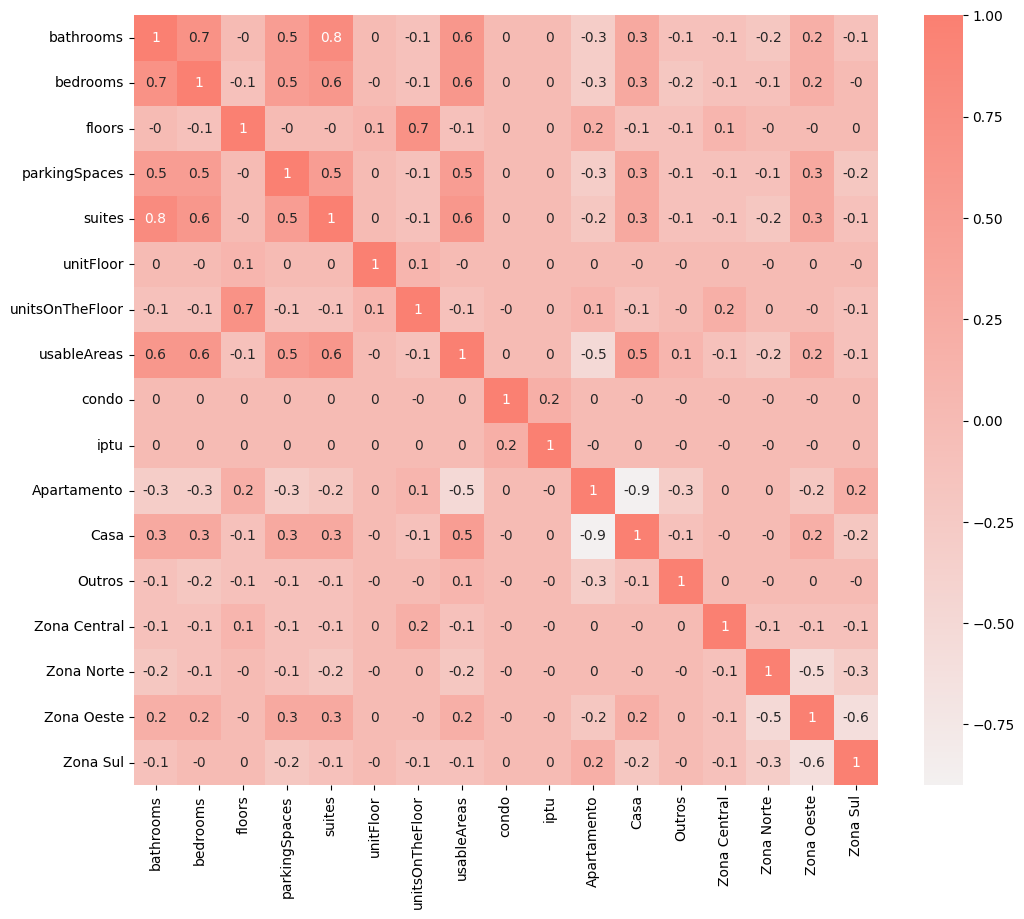

In [53]:
plt.figure(figsize=(12,10))

paleta = sns.color_palette('light:salmon', as_cmap=True)

sns.heatmap(dataframe_corr.round(1), cmap=paleta, annot=True)

**Construção dos modelos:** ajuste e previsão

In [54]:
from pyspark.ml.regression import LinearRegression

In [55]:
treino, teste = dataset_prep.randomSplit([0.7,0.3], seed=101)

In [56]:
treino.count()

48528

In [57]:
teste.count()

20911

In [58]:
lr = LinearRegression()


In [59]:
modelo_lr = lr.fit(treino)

In [60]:
previsao_treino = modelo_lr.transform(treino)

In [61]:
previsao_treino.show()

+--------------------+--------+------------------+
|            features|   label|        prediction|
+--------------------+--------+------------------+
|(17,[0,1,2,3,4,5,...|260000.0| 443266.0473681841|
|(17,[0,1,2,3,4,5,...|500000.0|1127455.8300452149|
|(17,[0,1,2,3,4,5,...|308615.0|111210.49949855916|
|(17,[0,1,2,3,4,5,...|279000.0|113587.95787652768|
|(17,[0,1,2,3,4,5,...|545000.0| 340703.7130779829|
|(17,[0,1,2,3,4,5,...|449000.0|390571.99595656525|
|(17,[0,1,2,3,4,5,...|479000.0| 444003.4297185277|
|(17,[0,1,2,3,4,5,...|420000.0|  720022.154216025|
|(17,[0,1,2,3,4,5,...|265000.0| 519406.0503738823|
|(17,[0,1,2,3,4,5,...|490000.0| 845483.5388435982|
|(17,[0,1,2,3,4,5,...|650000.0| 644931.4982486642|
|(17,[0,1,2,3,4,5,...|379900.0|448889.33390237275|
|(17,[0,1,2,3,4,5,...|449000.0| 714548.9501103363|
|(17,[0,1,2,3,4,5,...|190000.0|411726.94116262044|
|(17,[0,1,2,3,4,5,...|896000.0| 597499.4601550384|
|(17,[0,1,2,3,4,5,...|679000.0| 864544.0129259028|
|(17,[0,1,2,3,4,5,...|620000.0|

**Métricas**

In [62]:
# extraindo as métricas
resumo_treino = modelo_lr.summary


In [63]:
resumo_treino.r2

0.665587367845456

In [64]:
resumo_treino.rootMeanSquaredError

810348.9695316252

In [65]:
resumo_teste = modelo_lr.evaluate(teste)

In [66]:
resumo_teste.r2

0.6585207937774302

In [67]:
resumo_teste.rootMeanSquaredError

800525.9696828739

**Tabela resumo regressão linear**

In [68]:
print('Linear Regression')
print('='*30)
print('dados de treino')
print('='*30)
print('R²: %f' % resumo_treino.r2)
print('RMSE: %f' % resumo_treino.rootMeanSquaredError)
print('')
print('='*30)
print('dados de teste')
print('='*30)
print('R²: %f' % resumo_teste.r2)
print('RMSE: %f' % resumo_teste.rootMeanSquaredError)

Linear Regression
dados de treino
R²: 0.665587
RMSE: 810348.969532

dados de teste
R²: 0.658521
RMSE: 800525.969683


## **Árvore de decisão**

In [69]:
from pyspark.ml.regression import DecisionTreeRegressor

In [70]:
dtr = DecisionTreeRegressor(seed=101, maxDepth=7)

In [71]:
modelo_dtr = dtr.fit(treino)

In [72]:
dtr_treino = modelo_dtr.transform(treino)

In [73]:
dtr_treino.show()

+--------------------+--------+------------------+
|            features|   label|        prediction|
+--------------------+--------+------------------+
|(17,[0,1,2,3,4,5,...|260000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...|500000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...|308615.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...|279000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...|545000.0|     445137.460625|
|(17,[0,1,2,3,4,5,...|449000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...|479000.0|     445137.460625|
|(17,[0,1,2,3,4,5,...|420000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...|265000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...|490000.0|  820272.937751004|
|(17,[0,1,2,3,4,5,...|650000.0|  736254.943802521|
|(17,[0,1,2,3,4,5,...|379900.0|     445137.460625|
|(17,[0,1,2,3,4,5,...|449000.0|     445137.460625|
|(17,[0,1,2,3,4,5,...|190000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...|896000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...|679000.0|1158420.7653661144|
|(17,[0,1,2,3,4,5,...|620000.0|

**Métricas**

In [74]:
from pyspark.ml.evaluation import RegressionEvaluator

In [75]:
evaluator = RegressionEvaluator()

print(evaluator.evaluate(dtr_treino, {evaluator.metricName: 'r2'}))
print(evaluator.evaluate(dtr_treino, {evaluator.metricName: 'rmse'}))

0.7930752588471226
637436.5434260432


In [76]:
drt_teste = modelo_dtr.transform(teste)

In [77]:
drt_teste.show()

+--------------------+---------+------------------+
|            features|    label|        prediction|
+--------------------+---------+------------------+
|(17,[0,1,2,3,4,5,...| 199000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...| 350000.0|  820272.937751004|
|(17,[0,1,2,3,4,5,...| 340000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...| 430000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...| 600000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...| 439000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...| 333000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...| 948000.0|  736254.943802521|
|(17,[0,1,2,3,4,5,...| 459600.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...| 447600.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...| 360000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...| 407000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...| 310000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...|1400000.0|1289301.4891122277|
|(17,[0,1,2,3,4,5,...|1180000.0|1289301.4891122277|
|(17,[0,1,2,3,4,5,...|1299500.0|1158420.7653661144|
|(17,[0,1,2,

In [78]:
print('Decision Tree Regression')
print('='*30)
print('dados de treino')
print('='*30)
print('R²: %f' % evaluator.evaluate(dtr_treino, {evaluator.metricName: 'r2'}))
print('RMSE: %f' % evaluator.evaluate(dtr_treino, {evaluator.metricName: 'rmse'}))
print('')
print('='*30)
print('dados de teste')
print('='*30)
print('R²: %f' % evaluator.evaluate(drt_teste, {evaluator.metricName: 'rmse'}))
print('RMSE: %f' % evaluator.evaluate(drt_teste, {evaluator.metricName: 'r2'}))

Decision Tree Regression
dados de treino
R²: 0.793075
RMSE: 637436.543426

dados de teste
R²: 651518.489921
RMSE: 0.773813


**Random Forest**

In [79]:
from pyspark.ml.regression import RandomForestRegressor

In [80]:
rfr = RandomForestRegressor(seed=101, maxDepth=7, numTrees=10)

In [81]:
modelo_rfr = rfr.fit(treino)

In [82]:
rfr_treino = modelo_rfr.transform(treino)

In [83]:
rfr_treino.show()

+--------------------+--------+------------------+
|            features|   label|        prediction|
+--------------------+--------+------------------+
|(17,[0,1,2,3,4,5,...|260000.0|390218.33742322924|
|(17,[0,1,2,3,4,5,...|500000.0| 510060.6595782173|
|(17,[0,1,2,3,4,5,...|308615.0|360766.74127901345|
|(17,[0,1,2,3,4,5,...|279000.0|360766.74127901345|
|(17,[0,1,2,3,4,5,...|545000.0|  396904.928725379|
|(17,[0,1,2,3,4,5,...|449000.0|  492913.652312712|
|(17,[0,1,2,3,4,5,...|479000.0|433807.13396085694|
|(17,[0,1,2,3,4,5,...|420000.0| 664440.4325776277|
|(17,[0,1,2,3,4,5,...|265000.0|479615.50733929937|
|(17,[0,1,2,3,4,5,...|490000.0| 816123.0337632223|
|(17,[0,1,2,3,4,5,...|650000.0| 640247.1517314625|
|(17,[0,1,2,3,4,5,...|379900.0|403131.21721626434|
|(17,[0,1,2,3,4,5,...|449000.0|403131.21721626434|
|(17,[0,1,2,3,4,5,...|190000.0| 356904.3339549792|
|(17,[0,1,2,3,4,5,...|896000.0| 547828.3209496561|
|(17,[0,1,2,3,4,5,...|679000.0| 893791.6624292185|
|(17,[0,1,2,3,4,5,...|620000.0|

**Métricas**

In [84]:
print(evaluator.evaluate(rfr_treino, {evaluator.metricName: 'r2'}))
print(evaluator.evaluate(rfr_treino, {evaluator.metricName: 'rmse'}))

0.8017561510914318
623922.4426224458


In [85]:
rfr_teste = modelo_rfr.transform(teste)

In [86]:
rfr_teste.show()

+--------------------+---------+------------------+
|            features|    label|        prediction|
+--------------------+---------+------------------+
|(17,[0,1,2,3,4,5,...| 199000.0| 350678.0454640939|
|(17,[0,1,2,3,4,5,...| 350000.0| 792518.9735011571|
|(17,[0,1,2,3,4,5,...| 340000.0|479615.50733929937|
|(17,[0,1,2,3,4,5,...| 430000.0| 526635.5362588142|
|(17,[0,1,2,3,4,5,...| 600000.0| 526635.5362588142|
|(17,[0,1,2,3,4,5,...| 439000.0| 550795.8732599718|
|(17,[0,1,2,3,4,5,...| 333000.0| 356904.3339549792|
|(17,[0,1,2,3,4,5,...| 948000.0| 640247.1517314625|
|(17,[0,1,2,3,4,5,...| 459600.0| 356904.3339549792|
|(17,[0,1,2,3,4,5,...| 447600.0| 356904.3339549792|
|(17,[0,1,2,3,4,5,...| 360000.0| 356904.3339549792|
|(17,[0,1,2,3,4,5,...| 407000.0|  492913.652312712|
|(17,[0,1,2,3,4,5,...| 310000.0|412580.35636663495|
|(17,[0,1,2,3,4,5,...|1400000.0| 1375418.570408164|
|(17,[0,1,2,3,4,5,...|1180000.0| 1375418.570408164|
|(17,[0,1,2,3,4,5,...|1299500.0|1111896.8209940076|
|(17,[0,1,2,

In [87]:
print('Random Forest Regression')
print('='*30)
print('dados de treino')
print('='*30)
print('R²: %f' % evaluator.evaluate(rfr_treino, {evaluator.metricName: 'r2'}))
print('RMSE: %f' % evaluator.evaluate(rfr_treino, {evaluator.metricName: 'rmse'}))
print('')
print('='*30)
print('dados de teste')
print('='*30)
print('R²: %f' % evaluator.evaluate(rfr_teste, {evaluator.metricName: 'rmse'}))
print('RMSE: %f' % evaluator.evaluate(rfr_teste, {evaluator.metricName: 'r2'}))

Random Forest Regression
dados de treino
R²: 0.801756
RMSE: 623922.442622

dados de teste
R²: 626981.467738
RMSE: 0.790530


**Aplicando técnicas de otimização**

Árvore de decisão com Cross Validation

In [88]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import DecisionTreeRegressor

In [89]:
dtr = DecisionTreeRegressor()

In [90]:
grid = ParamGridBuilder()\
  .addGrid(dtr.maxDepth, [2, 5, 7, 10])\
  .addGrid(dtr.maxBins, [10, 32, 45])\
  .build()

In [91]:
evaluator = RegressionEvaluator()

In [92]:
dtr_cv = CrossValidator(
    estimator=dtr,
    estimatorParamMaps=grid,
    evaluator=evaluator,
    numFolds=3,
    seed=101
)

In [93]:
modelo_dtr_cv = dtr_cv.fit(treino)

In [94]:
# gerando previsões
dtr_cv_teste = modelo_dtr_cv.transform(teste)

In [95]:
print('Árvore de decisão')
print('='*30)
print('sem cross validation')
print('='*30)
print('R²: %f' % evaluator.evaluate(drt_teste, {evaluator.metricName: 'r2'}))
print('RMSE: %f' % evaluator.evaluate(drt_teste, {evaluator.metricName: 'rmse'}))
print('')
print('='*30)
print('com cross validation')
print('='*30)
print('R²: %f' % evaluator.evaluate(dtr_cv_teste, {evaluator.metricName: 'rmse'}))
print('RMSE: %f' % evaluator.evaluate(dtr_cv_teste, {evaluator.metricName: 'r2'}))

Árvore de decisão
sem cross validation
R²: 0.773813
RMSE: 651518.489921

com cross validation
R²: 628239.121555
RMSE: 0.789688


random forest com cross validation

In [96]:
from pyspark.ml.regression import RandomForestRegressor

In [97]:
rfr = RandomForestRegressor()

In [98]:
grid = ParamGridBuilder()\
  .addGrid(rfr.numTrees, [10,20,30])\
  .addGrid(rfr.maxDepth, [5, 10])\
  .addGrid(rfr.maxBins, [10, 32, 45])\
  .build()

In [99]:
evaluator = RegressionEvaluator()

In [100]:
rfr_cv = CrossValidator(
    estimator=rfr,
    estimatorParamMaps=grid,
    evaluator=evaluator,
    numFolds=3,
    seed=101
)

In [101]:
modelo_rfr_cv = rfr_cv.fit(treino)

In [102]:
rfr_cv_teste = modelo_rfr_cv.transform(teste)

In [103]:
print('Random Forest')
print('='*30)
print('sem cross validation')
print('='*30)
print('R²: %f' % evaluator.evaluate(rfr_teste, {evaluator.metricName: 'r2'}))
print('RMSE: %f' % evaluator.evaluate(rfr_teste, {evaluator.metricName: 'rmse'}))
print('')
print('='*30)
print('com cross validation')
print('='*30)
print('R²: %f' % evaluator.evaluate(rfr_cv_teste, {evaluator.metricName: 'rmse'}))
print('RMSE: %f' % evaluator.evaluate(rfr_cv_teste, {evaluator.metricName: 'r2'}))

Random Forest
sem cross validation
R²: 0.790530
RMSE: 626981.467738

com cross validation
R²: 565998.457572
RMSE: 0.829296


**Prevendo resultados**

In [104]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+-----------+----+------+------------+----------+----------+--------+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  label|condo| iptu|Apartamento|Casa|Outros|Zona Central|Zona Norte|Zona Oeste|Zona Sul|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+-----------+----+------+------------+----------+----------+--------+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|  0.0|          0|   0|     1|           0|         0|         1|       0|
|660

In [105]:
x

['bathrooms',
 'bedrooms',
 'floors',
 'parkingSpaces',
 'suites',
 'unitFloor',
 'unitsOnTheFloor',
 'usableAreas',
 'condo',
 'iptu',
 'Apartamento',
 'Casa',
 'Outros',
 'Zona Central',
 'Zona Norte',
 'Zona Oeste',
 'Zona Sul']

In [111]:
novo_imovel =[{
 'bathrooms':2,
 'bedrooms':2,
 'floors':2,
 'parkingSpaces':1,
 'suites':1,
 'unitFloor':0,
 'unitsOnTheFloor':200,
 'usableAreas':200,
 'condo':200,
 'iptu':0,
 'Apartamento':0,
 'Casa':1,
 'Outros':0,
 'Zona Central':0,
 'Zona Norte':0,
 'Zona Oeste':0,
 'Zona Sul':1,
 'label':0
}]

In [112]:
meu_imovel = spark.createDataFrame(novo_imovel)

In [113]:
meu_imovel.show()

+-----------+----+------+------------+----------+----------+--------+---------+--------+-----+------+----+-----+-------------+------+---------+---------------+-----------+
|Apartamento|Casa|Outros|Zona Central|Zona Norte|Zona Oeste|Zona Sul|bathrooms|bedrooms|condo|floors|iptu|label|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|
+-----------+----+------+------------+----------+----------+--------+---------+--------+-----+------+----+-----+-------------+------+---------+---------------+-----------+
|          0|   1|     0|           0|         0|         0|       1|        2|       2|  200|     2|   0|    0|            1|     1|        0|            200|        200|
+-----------+----+------+------------+----------+----------+--------+---------+--------+-----+------+----+-----+-------------+------+---------+---------------+-----------+



In [109]:
assembler = VectorAssembler(inputCols = x, outputCol = 'features')

In [114]:
imovel_vetorizado = assembler.transform(meu_imovel).select('features', 'label')

In [115]:
imovel_vetorizado.show()

+--------------------+-----+
|            features|label|
+--------------------+-----+
|(17,[0,1,2,3,4,6,...|    0|
+--------------------+-----+



In [116]:
modelo_rfr_cv.transform(imovel_vetorizado).show()

+--------------------+-----+-----------------+
|            features|label|       prediction|
+--------------------+-----+-----------------+
|(17,[0,1,2,3,4,6,...|    0|2888169.329643737|
+--------------------+-----+-----------------+

